In [1]:
# %%
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv

In [2]:
STATE = "13"
COUNTIES = ["121", "089", "067", "135"]
RANDOM_STATE = 42
N_CLUSTERS = 5

X_df = pd.read_parquet(
    "../data/processed_predictors/atlanta_2023_predictor_dataset.parquet"
)

y_df = pd.read_parquet(
    "../data/processed_job_accessibility/accessibility_state-GA_counties-121-089-067-135_year-2023_thresholds-15-30-45-60.parquet"
)

In [3]:
# %%
target_cols = [
    "jobs_15min",
    "jobs_30min",
    "jobs_45min",
    "jobs_60min"
]

weights = np.array([1.0, 0.7, 0.4, 0.2])

# ensure clean ordering (important for stability)
y_df = y_df.sort_values("from_id").reset_index(drop=True)

band_0_15 = y_df["jobs_15min"].clip(lower=0)
band_15_30 = (y_df["jobs_30min"] - y_df["jobs_15min"]).clip(lower=0)
band_30_45 = (y_df["jobs_45min"] - y_df["jobs_30min"]).clip(lower=0)
band_45_60 = (y_df["jobs_60min"] - y_df["jobs_45min"]).clip(lower=0)

weighted_sum = (
      weights[0] * band_0_15
    + weights[1] * band_15_30
    + weights[2] * band_30_45
    + weights[3] * band_45_60
)

# log transform for skew stability (same as before, but now on corrected signal)
y_df["access_index"] = np.log1p(weighted_sum)

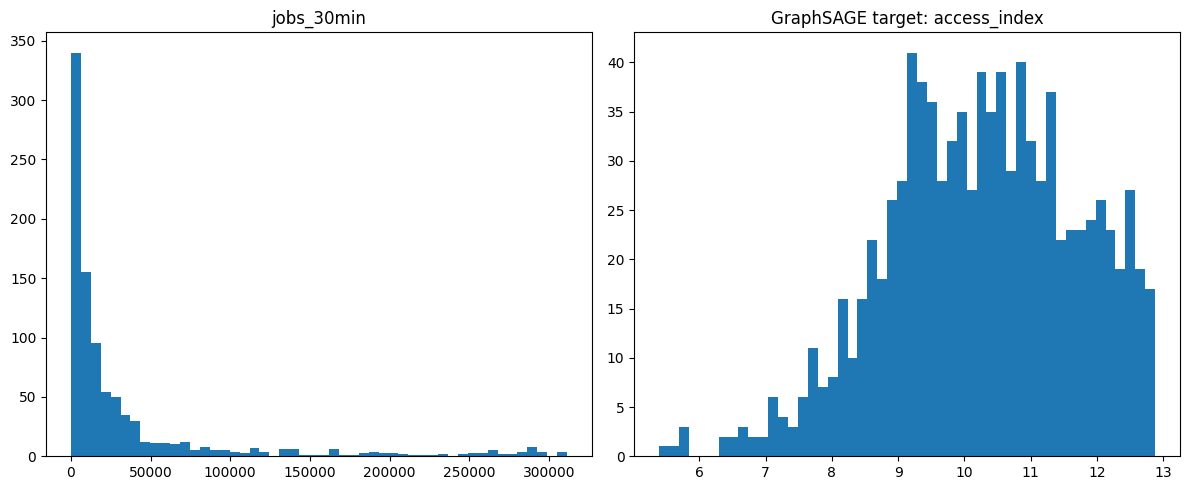

In [4]:
# %%
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(y_df["jobs_30min"], bins=50)
axes[0].set_title("jobs_30min")

axes[1].hist(y_df["access_index"], bins=50)
axes[1].set_title("GraphSAGE target: access_index")

plt.tight_layout()
plt.show()

In [5]:
df = X_df.merge(
    y_df[["from_id"] + ["access_index"]],
    left_on="tract_id",
    right_on="from_id",
    how="inner"
)

url = (
    f"https://www2.census.gov/geo/tiger/TIGER2023/"
    f"TRACT/tl_2023_{STATE}_tract.zip"
)

tracts = gpd.read_file(url)
tracts = tracts[tracts["COUNTYFP"].isin(COUNTIES)].copy()
tracts["tract_id"] = tracts["GEOID"].astype(str)

df = df.merge(
    tracts[["tract_id", "geometry"]],
    on="tract_id",
    how="left"
)

gdf = gpd.GeoDataFrame(df, geometry="geometry", crs=tracts.crs)
gdf = gdf.to_crs(epsg=5070).copy()

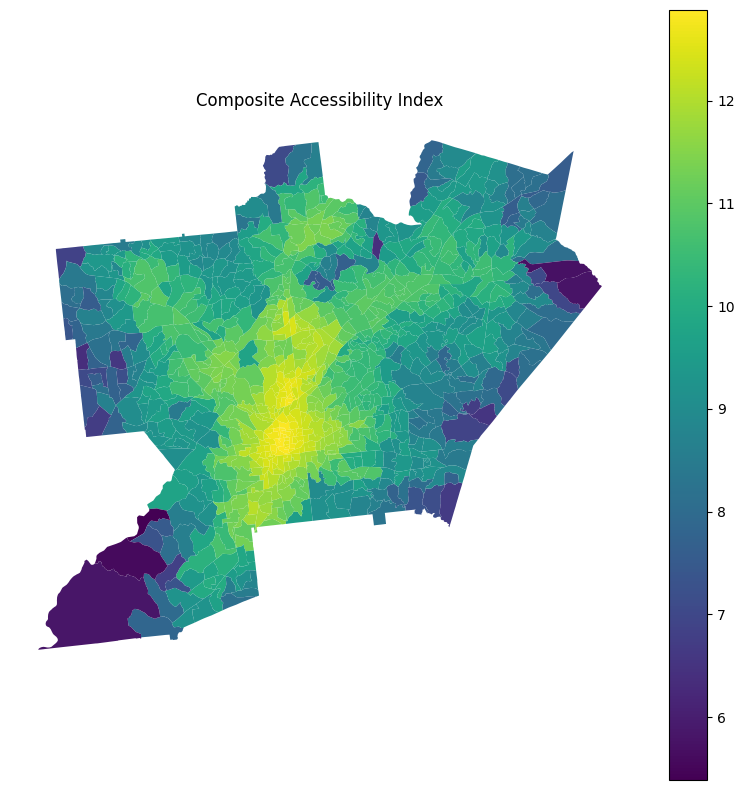

In [6]:
gdf["access_index_raw"] = gdf["access_index"]

fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    column="access_index_raw",
    cmap="viridis",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"}
)

ax.set_title("Composite Accessibility Index")
ax.axis("off")
plt.show()

In [7]:
gdf["centroid"] = gdf.geometry.centroid
gdf["x"] = gdf.centroid.x
gdf["y"] = gdf.centroid.y

coords = np.column_stack([gdf["x"], gdf["y"]])

k = 8  # neighborhood size

from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=k)
nn.fit(coords)

dist, idx = nn.kneighbors(coords)

edges = []
for i in range(len(coords)):
    for j in idx[i]:
        if i != j:
            edges.append((i, j))

edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

In [8]:
drop_cols = [
    "tract_id",
    "from_id",
    "geometry",
    "centroid",
    "x",
    "y",
    "cluster",
    "access_index",
    "access_index_raw"
]

feature_cols = [c for c in gdf.columns if c not in drop_cols]

X_np = gdf[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0).values

scaler = StandardScaler()
X_np = scaler.fit_transform(X_np)

X = torch.tensor(X_np, dtype=torch.float)
y = torch.tensor(gdf["access_index"].values, dtype=torch.float)

In [9]:
coords = np.column_stack([gdf["x"], gdf["y"]])

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init="auto")
gdf["cluster"] = kmeans.fit_predict(coords)

In [10]:
class GraphSAGE(torch.nn.Module):

    def __init__(self, in_channels, hidden=64):

        super().__init__()

        self.conv1 = SAGEConv(in_channels, hidden)
        self.conv2 = SAGEConv(hidden, hidden)
        self.conv3 = SAGEConv(hidden, hidden)

        self.lin = torch.nn.Linear(hidden, 1)

    def forward(self, x, edge_index):

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        x = self.conv3(x, edge_index)
        x = F.relu(x)

        x = self.lin(x)

        return x.squeeze()

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

results = []
all_predictions = []

for test_cluster in range(N_CLUSTERS):

    print(f"\nTEST CLUSTER {test_cluster}")

    train_idx = (gdf["cluster"] != test_cluster).values
    test_idx = (gdf["cluster"] == test_cluster).values

    model = GraphSAGE(in_channels=X.shape[1]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
    loss_fn = torch.nn.MSELoss()

    x = X.to(device)
    y_t = y.to(device)
    edge = edge_index.to(device)

    train_mask = torch.tensor(train_idx, dtype=torch.bool).to(device)
    test_mask = torch.tensor(test_idx, dtype=torch.bool).to(device)

    # TRAINING LOOP
    model.train()
    for epoch in range(200):

        optimizer.zero_grad()

        out = model(x, edge)

        loss = loss_fn(out[train_mask], y_t[train_mask])

        loss.backward()
        optimizer.step()

    # EVAL
    model.eval()
    with torch.no_grad():
        pred = model(x, edge).cpu().numpy()

    y_true = y.cpu().numpy()

    y_pred_test = pred[test_idx]
    y_true_test = y_true[test_idx]

    mae = mean_absolute_error(y_true_test, y_pred_test)
    rmse = np.sqrt(mean_squared_error(y_true_test, y_pred_test))
    r2 = r2_score(y_true_test, y_pred_test)

    results.append({
        "cluster": test_cluster,
        "mae": mae,
        "rmse": rmse,
        "r2": r2
    })

    fold_preds = pd.DataFrame({
        "tract_id": gdf["tract_id"].values[test_idx],
        "cluster": test_cluster,
        "actual": y_true_test,
        "predicted": y_pred_test
    })

    all_predictions.append(fold_preds)


TEST CLUSTER 0

TEST CLUSTER 1

TEST CLUSTER 2

TEST CLUSTER 3

TEST CLUSTER 4


In [12]:
results_df = pd.DataFrame(results)

print(results_df)
print(results_df[["mae", "rmse", "r2"]].mean())

   cluster       mae      rmse        r2
0        0  0.952911  1.262199 -0.258997
1        1  1.123124  1.484541  0.016265
2        2  0.967751  1.274570  0.072019
3        3  0.912242  1.211016 -0.085263
4        4  0.847003  1.052202 -0.120306
mae     0.960606
rmse    1.256906
r2     -0.075257
dtype: float64


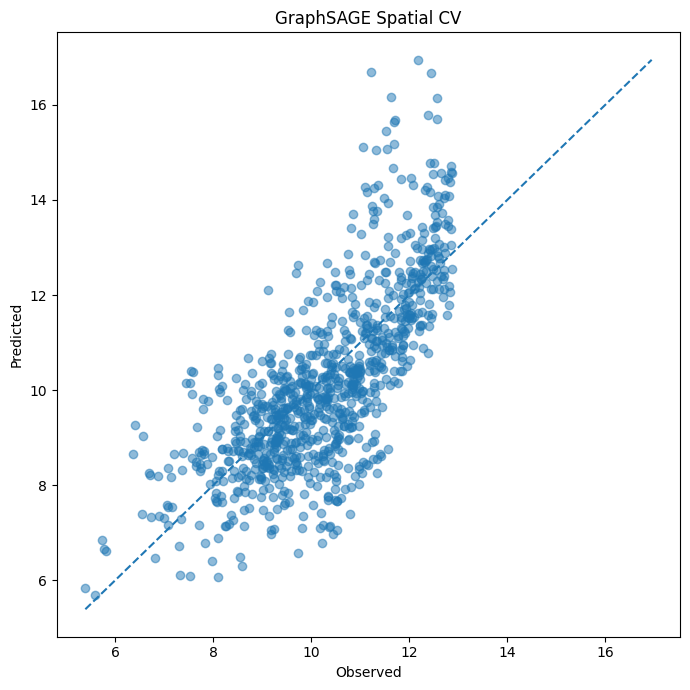

In [13]:
predictions_df = pd.concat(all_predictions, ignore_index=True)

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(predictions_df["actual"], predictions_df["predicted"], alpha=0.5)

min_val = min(predictions_df["actual"].min(), predictions_df["predicted"].min())
max_val = max(predictions_df["actual"].max(), predictions_df["predicted"].max())

ax.plot([min_val, max_val], [min_val, max_val], "--")

ax.set_xlabel("Observed")
ax.set_ylabel("Predicted")
ax.set_title("GraphSAGE Spatial CV")

plt.tight_layout()
plt.show()

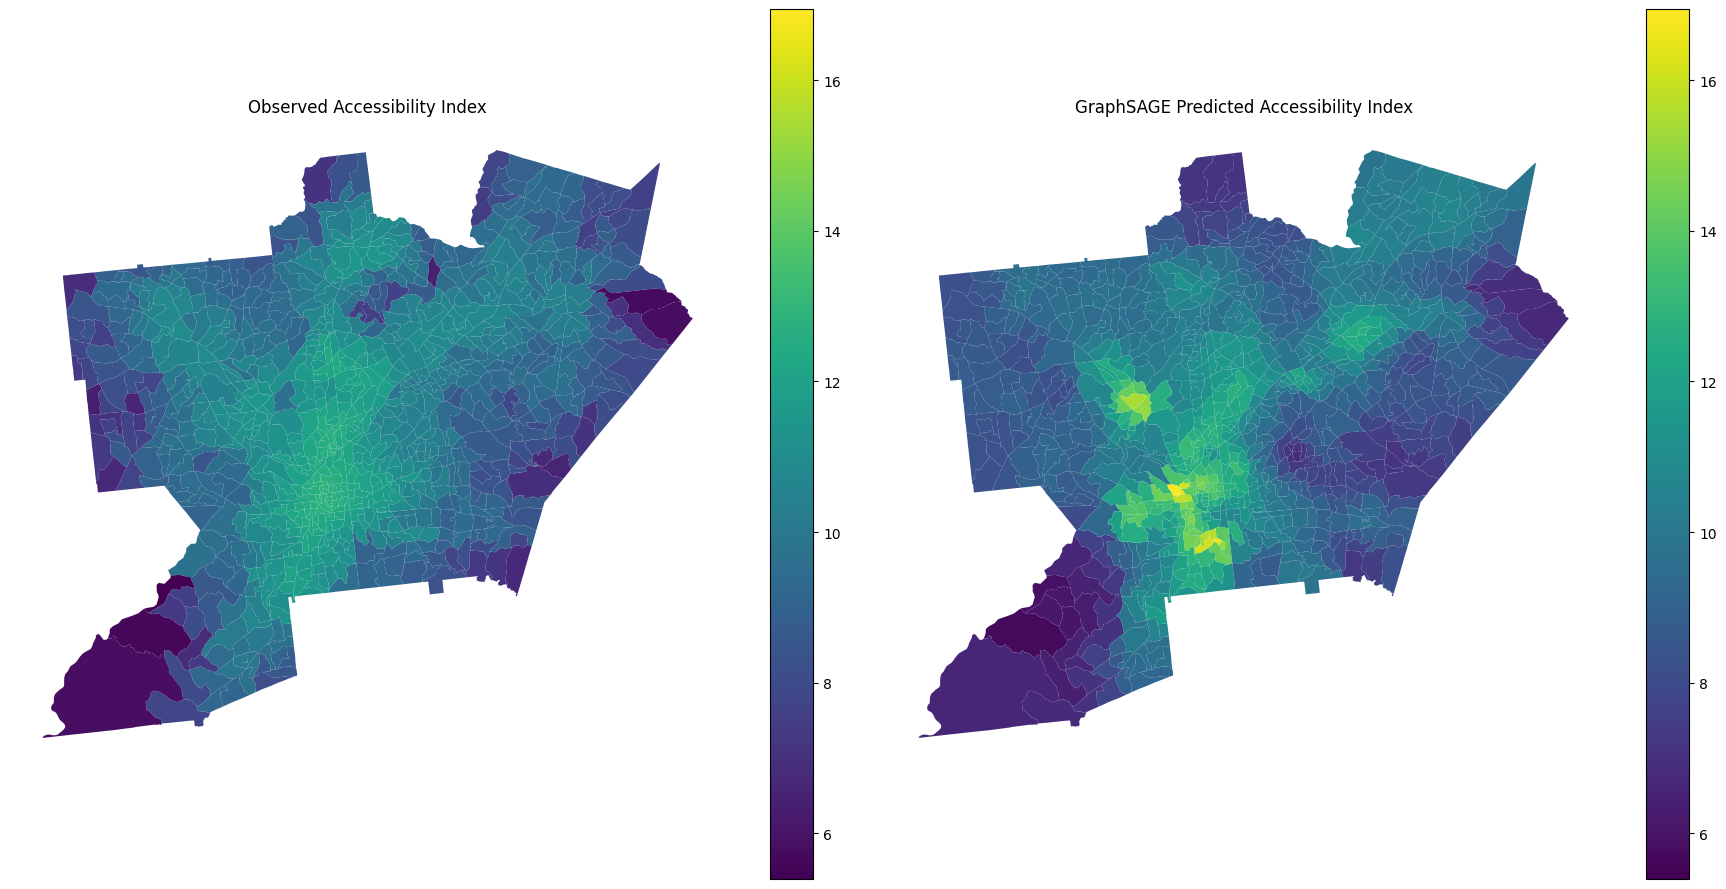

In [14]:
# %%
map_gdf = gdf[["tract_id", "geometry"]].merge(
    predictions_df[["tract_id", "actual", "predicted"]],
    on="tract_id",
    how="inner"
)

map_gdf = gpd.GeoDataFrame(map_gdf, geometry="geometry", crs=gdf.crs)

# shared scale (important for comparability)
vmin = min(map_gdf["actual"].min(), map_gdf["predicted"].min())
vmax = max(map_gdf["actual"].max(), map_gdf["predicted"].max())

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

map_gdf.plot(
    column="actual",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    ax=axes[0],
    legend=True
)

axes[0].set_title("Observed Accessibility Index")
axes[0].axis("off")

map_gdf.plot(
    column="predicted",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    ax=axes[1],
    legend=True
)

axes[1].set_title("GraphSAGE Predicted Accessibility Index")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [15]:
# %%
from torch_geometric.explain import Explainer, GNNExplainer

# %%
# GLOBAL GRAPH EXPLANATIONS

model.eval()

explainer = Explainer(
    model=model,
    algorithm=GNNExplainer(
        epochs=10
    ),
    explanation_type="model",
    node_mask_type="attributes",
    edge_mask_type=None,
    model_config=dict(
        mode="regression",
        task_level="node",
        return_type="raw"
    ),
)

In [16]:
# %%
# SAMPLE NODES FOR GLOBAL EXPLANATION

num_nodes = x.shape[0]

sample_size = num_nodes

sample_nodes = np.random.choice(
    num_nodes,
    size=sample_size,
    replace=False
)

all_feature_masks = []

In [17]:

# %%
# RUN EXPLANATIONS

for i, node_idx in enumerate(sample_nodes):

    if i % 10 == 0:
        print(f"Explaining node {i+1} / {sample_size}")

    explanation = explainer(
        x=x,
        edge_index=edge,
        index=int(node_idx)
    )

    node_mask = (
        explanation.node_mask
        .abs()
        .mean(dim=0)
        .detach()
        .cpu()
        .numpy()
    )

    all_feature_masks.append(node_mask)

Explaining node 1 / 936
Explaining node 11 / 936
Explaining node 21 / 936
Explaining node 31 / 936
Explaining node 41 / 936
Explaining node 51 / 936
Explaining node 61 / 936
Explaining node 71 / 936
Explaining node 81 / 936
Explaining node 91 / 936
Explaining node 101 / 936
Explaining node 111 / 936
Explaining node 121 / 936
Explaining node 131 / 936
Explaining node 141 / 936
Explaining node 151 / 936
Explaining node 161 / 936
Explaining node 171 / 936
Explaining node 181 / 936
Explaining node 191 / 936
Explaining node 201 / 936
Explaining node 211 / 936
Explaining node 221 / 936
Explaining node 231 / 936
Explaining node 241 / 936
Explaining node 251 / 936
Explaining node 261 / 936
Explaining node 271 / 936
Explaining node 281 / 936
Explaining node 291 / 936
Explaining node 301 / 936
Explaining node 311 / 936
Explaining node 321 / 936
Explaining node 331 / 936
Explaining node 341 / 936
Explaining node 351 / 936
Explaining node 361 / 936
Explaining node 371 / 936
Explaining node 381 / 9

In [18]:
# CREATE NODE-LEVEL IMPORTANCE TABLE

all_feature_masks = np.array(all_feature_masks)

node_importance_df = pd.DataFrame(
    all_feature_masks,
    columns=feature_cols
)

node_importance_df["node_idx"] = sample_nodes

In [19]:
# %%
# GLOBAL FEATURE IMPORTANCE

global_importance = all_feature_masks.mean(axis=0)

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": global_importance
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

importance_df.head(20)

,feature,importance
26,pct_bike_commute,0.023429
37,distance_to_cbd_km,0.023342
25,pct_walk_commute,0.023163
39,pct_black,0.023155
23,pct_public_transit_commute,0.023140
34,housing_density,0.023127
1,population_density,0.023107
14,snap_participation_rate,0.023029
18,pct_graduate_degree,0.023026
38,pct_white_non_hispanic,0.023020


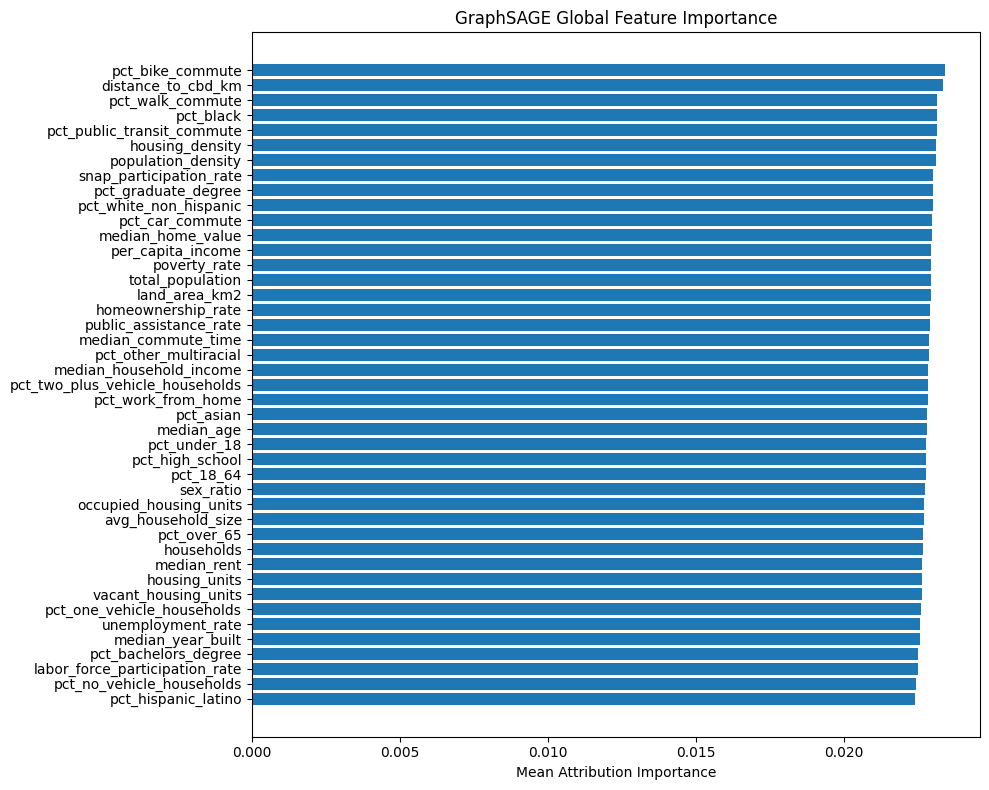

In [20]:
# GLOBAL FEATURE IMPORTANCE PLOT

top_n = 100

plot_df = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    plot_df["feature"][::-1],
    plot_df["importance"][::-1]
)

ax.set_title("GraphSAGE Global Feature Importance")
ax.set_xlabel("Mean Attribution Importance")

plt.tight_layout()
plt.show()